<>:198: SyntaxWarning: invalid escape sequence '\%'
<>:199: SyntaxWarning: invalid escape sequence '\%'
<>:198: SyntaxWarning: invalid escape sequence '\%'
<>:199: SyntaxWarning: invalid escape sequence '\%'
/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_5194/1940323172.py:198: SyntaxWarning: invalid escape sequence '\%'
  ax.fill_between(dates, q5, q95, alpha=0.15, label="5–95\% band")
/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_5194/1940323172.py:199: SyntaxWarning: invalid escape sequence '\%'
  ax.fill_between(dates, q25, q75, alpha=0.25, label="25–75\% band")


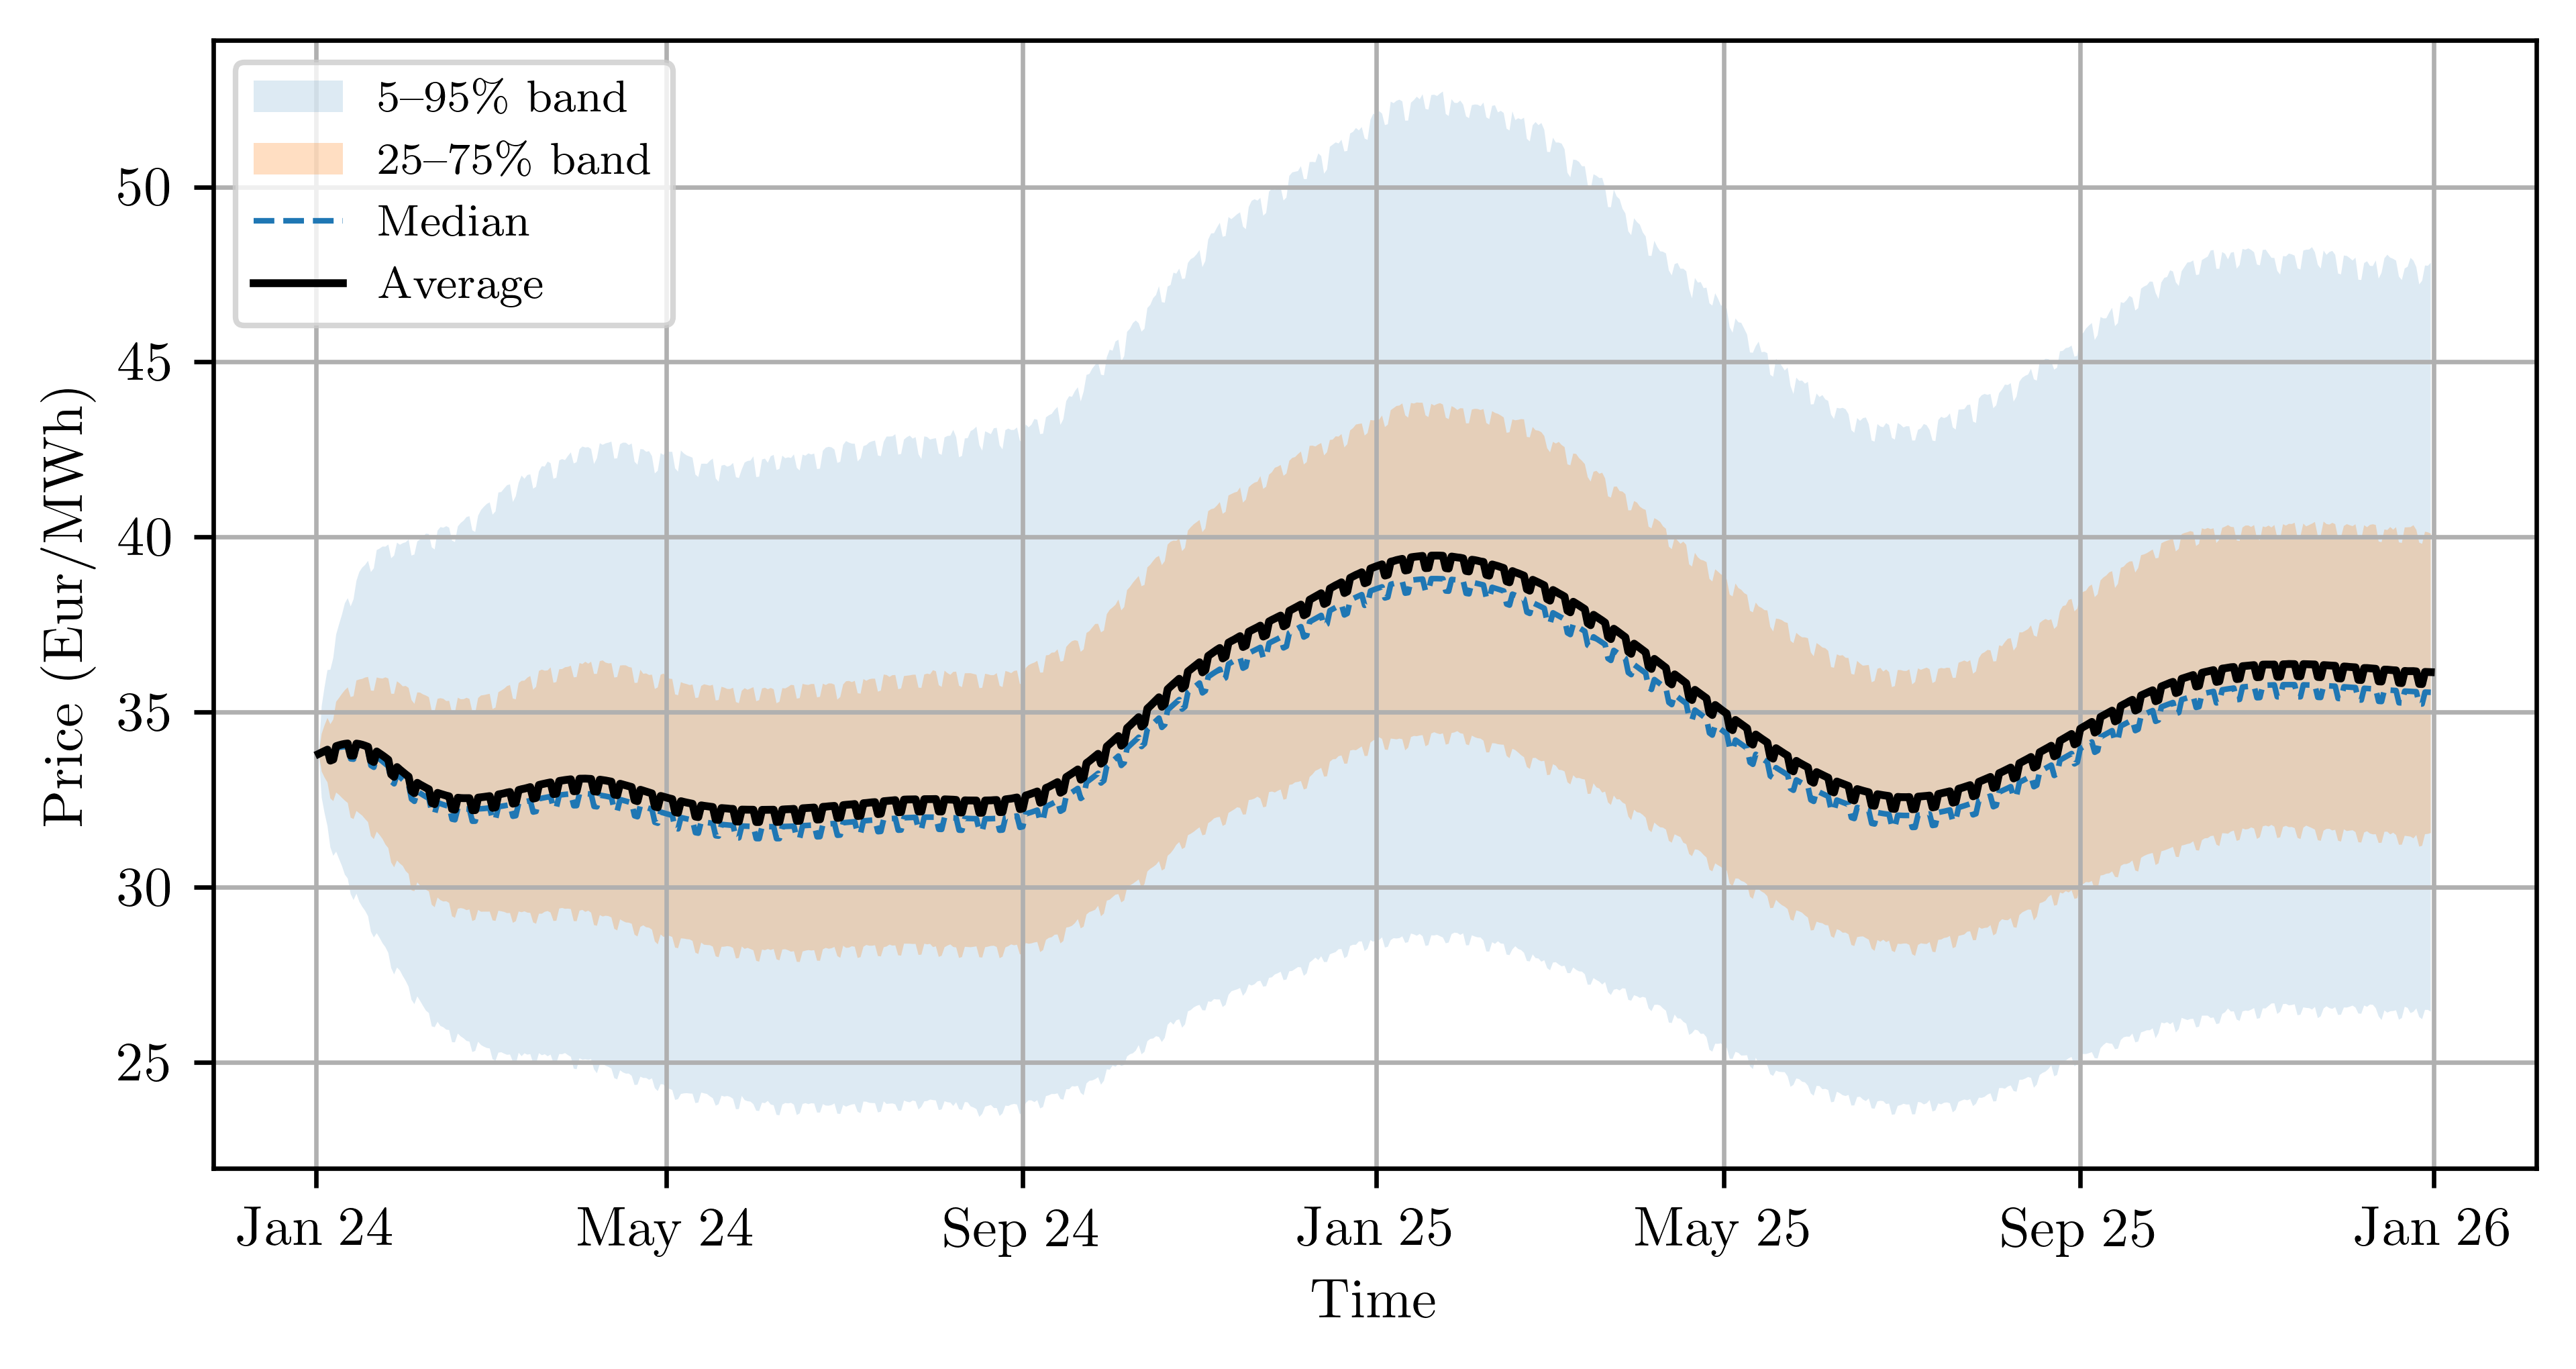

In [1]:
import numpy as np
import pandas as pd
import re
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

dt = 1.0  # day
seed = 123
n_paths_max = 10000

forward_csv_path = "../data/forward_prices.csv"

forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Load spot data and lift it onto a full calendar-day grid
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

spot_obs = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Build a daily calendar grid shared by spot and forwards
# ----------------------------
calendar_dates = pd.date_range(
    start=max(spot_obs["date"].min(), forward_curve["date"].min()),
    end=min(spot_obs["date"].max(), forward_curve["date"].max()),
    freq="D",
)

data = pd.DataFrame({"date": calendar_dates})
data = data.merge(spot_obs, on="date", how="left")
data["spot_price"] = data["spot_price"].ffill()
data = data.merge(forward_curve, on="date", how="left")

if data[["spot_price", "forward_price"]].isna().any().any():
    raise ValueError("Calendar-day grid contains missing spot or forward prices.")

# ----------------------------
# Joint estimation of seasonality + AR(1)  [calendar days]
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build price-process arrays on the calendar-day grid
# ----------------------------
data  = data.sort_values("date").reset_index(drop=True)
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# Transition from step i-1 to i spans h = t_arr[i] - t_arr[i-1] calendar days.
# On the daily calendar grid used here, h = 1 for ordinary steps, but the
# per-step formula is kept so the notebook remains robust to non-daily gaps.
# ----------------------------
rng    = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

S = simulate_from_Z(Z, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr, kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

sim = pd.DataFrame(S, columns=[f"path_{i+1}" for i in range(S.shape[1])])
sim.insert(0, "date", data["date"])

sim.to_csv("../data/spot_price_sims.csv", index=False)

probs = [0.05, 0.25, 0.50, 0.75, 0.95]
levels = ["q5%", "q25%", "q50%", "mean", "q75%", "q95%"]

label_map = {
    "q5%": "5% quantile",
    "q25%": "25% quantile",
    "q50%": "50% quantile",
    "q75%": "75% quantile",
    "q95%": "95% quantile",
    "mean": "Average"
}

path_cols = [col for col in sim.columns if col != "date"]

plot_df = pd.DataFrame({
    "date": sim["date"],
    "mean": sim[path_cols].mean(axis=1),
    "q5%": sim[path_cols].quantile(0.05, axis=1),
    "q25%": sim[path_cols].quantile(0.25, axis=1),
    "q50%": sim[path_cols].quantile(0.50, axis=1),
    "q75%": sim[path_cols].quantile(0.75, axis=1),
    "q95%": sim[path_cols].quantile(0.95, axis=1),
})

plot_long = plot_df.melt(
    id_vars="date",
    value_vars=["q5%", "q25%", "q50%", "mean", "q75%", "q95%"],
    var_name="series",
    value_name="price"
)

plot_long["series"] = pd.Categorical(plot_long["series"], categories=levels, ordered=True)
plot_long["label"] = plot_long["series"].map(label_map)

label_df = (
    plot_long.sort_values("date")
    .groupby("series", observed=False)
    .tail(1)
    .copy()
)

mpl.rcParams.update({
    "text.usetex": True,          # Use LaTeX
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

dates = sim["date"]

# Extract series
mean = plot_df["mean"]
q5  = plot_df["q5%"]
q25 = plot_df["q25%"]
q50 = plot_df["q50%"]
q75 = plot_df["q75%"]
q95 = plot_df["q95%"]

# Quantile bands
ax.fill_between(dates, q5, q95, alpha=0.15, label="5–95\% band")
ax.fill_between(dates, q25, q75, alpha=0.25, label="25–75\% band")

# Median
ax.plot(dates, q50, linestyle="--", linewidth=1.0, label="Median")

# Mean
ax.plot(dates, mean, linewidth=1.4, color="black", label="Average")

ax.set_xlabel("Time")
ax.set_ylabel("Price (Eur/MWh)")
ax.grid(True)

# Ticks every 4 months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))

# Label like: Jan 25, May 25, Sep 25
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/spot_prices_plot.png")
plt.show()

Jarque-Bera:  stat=169.8396,  p-value=0.0000  (skew=-0.1977, excess kurt=2.3313)
Shapiro-Wilk: stat=0.9492,  p-value=0.0000


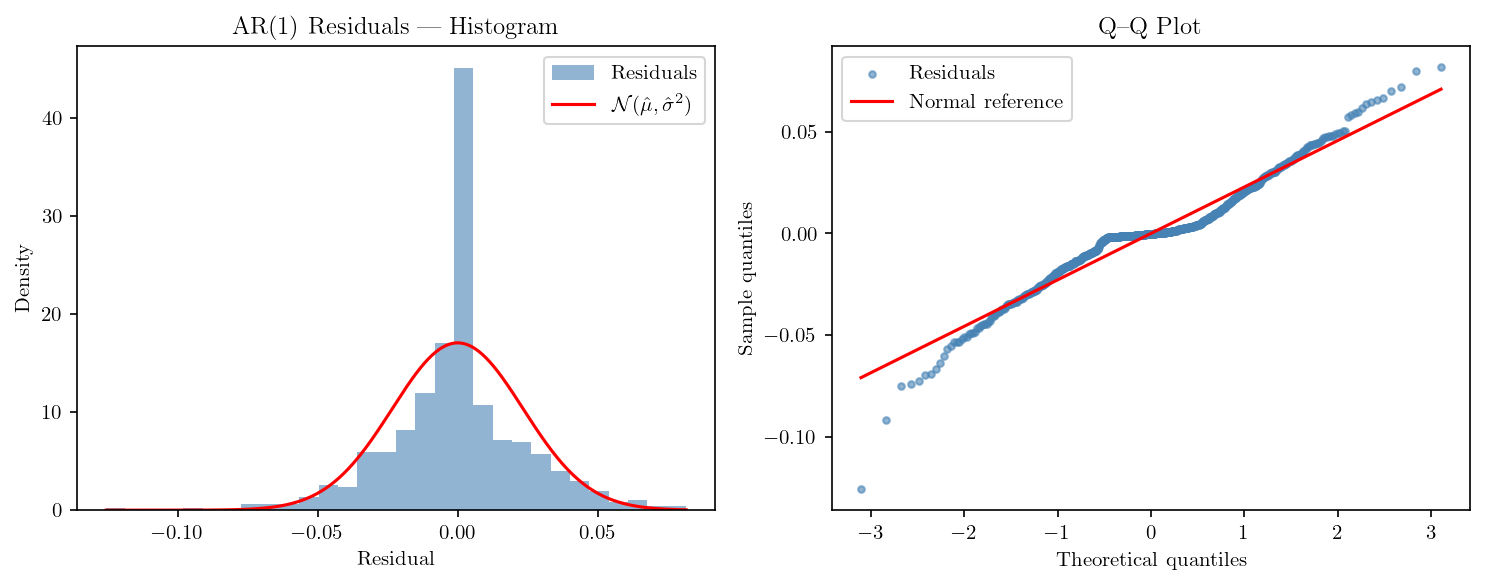

In [2]:

from scipy import stats

residuals = fit_joint.resid

# --- Normality tests ---
jb_stat, jb_p = stats.jarque_bera(residuals)
sw_stat, sw_p = stats.shapiro(residuals)
skewness      = stats.skew(residuals)
excess_kurt   = stats.kurtosis(residuals)   # Fisher definition: excess kurtosis (normal = 0)

print(f"Jarque-Bera:  stat={jb_stat:.4f},  p-value={jb_p:.4f}  (skew={skewness:.4f}, excess kurt={excess_kurt:.4f})")
print(f"Shapiro-Wilk: stat={sw_stat:.4f},  p-value={sw_p:.4f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

# Histogram with fitted normal
ax = axes[0]
mu, std = residuals.mean(), residuals.std(ddof=1)
x_range = np.linspace(residuals.min(), residuals.max(), 300)
ax.hist(residuals, bins=30, density=True, alpha=0.6, color="steelblue", label="Residuals")
ax.plot(x_range, stats.norm.pdf(x_range, mu, std), "r-", linewidth=1.5, label=r"$\mathcal{N}(\hat{\mu},\hat{\sigma}^2)$")
ax.set_xlabel("Residual")
ax.set_ylabel("Density")
ax.set_title("AR(1) Residuals — Histogram")
ax.legend()

# Q-Q plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, s=10, alpha=0.6, color="steelblue", label="Residuals")
ax.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5, label="Normal reference")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.set_title("Q–Q Plot")
ax.legend()

fig.tight_layout()
plt.savefig("../../fig/Plots/residual_diagnostics.png")
plt.show()


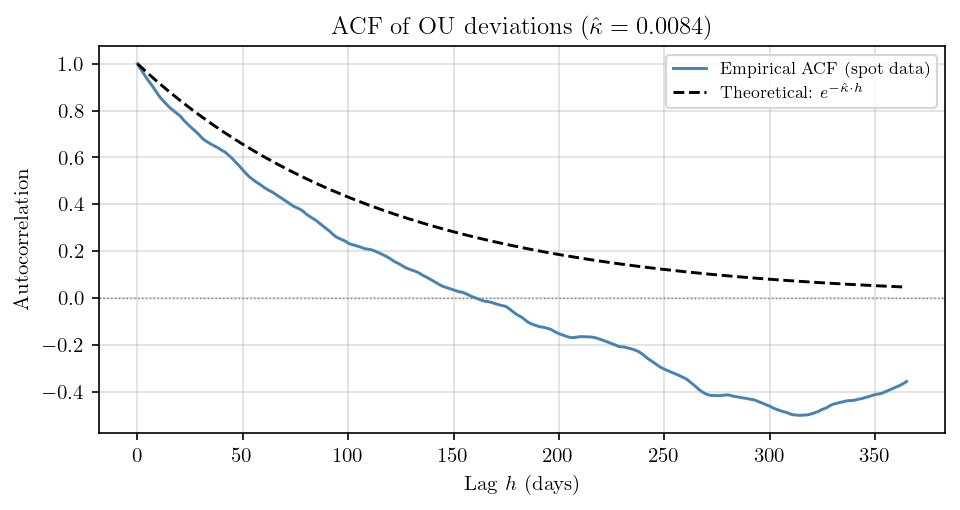

In [8]:
# --- Theoretical vs empirical ACF of the OU deviation process Y ---
max_lag = 365  # days

lags = np.arange(0, max_lag + 1)
acf_theory = np.exp(-kappa_hat * lags * dt)

# Observed OU deviations: strip forward-curve drift from actual log spot
Y_obs = data["X"].values - m
acf_obs = sm.tsa.acf(Y_obs, nlags=max_lag, fft=True)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=150)

ax.plot(lags, acf_obs,    color="steelblue", linewidth=1.4, label="Empirical ACF (spot data)")
ax.plot(lags, acf_theory, color="black",     linewidth=1.4, linestyle="--",
        label=r"Theoretical: $e^{-\hat\kappa \cdot h}$")

ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
ax.set_xlabel("Lag $h$ (days)")
ax.set_ylabel("Autocorrelation")
ax.set_title(r"ACF of OU deviations ($\hat\kappa = {:.4f}$)".format(kappa_hat))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()
